In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import datetime as dt
from matplotlib import pyplot as plt
from src.post_process_functions import format_output
from src.data import DATA_OUT_PROC, DATA_FIGURE

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
#load data (model)
res_savename_ext = "post_processed_flags_labelled_reports_meta-llama_llama-4-scout-17b-16e-instruct_v230925"
extracted_df = pd.read_csv(DATA_OUT_PROC / (res_savename_ext+".csv"))

#load data (labelled)
res_savename_lab = "post_processed_labelled_reports_impacts_all_v240925"
labelled_df = pd.read_csv(DATA_OUT_PROC / (res_savename_lab+".csv"))

#split_lowest = False
#suffix = "_geo_split_lowest" if split_lowest else "_geo"
#suffix+="_v250925"
##load geocoded data
#extracted_df = gpd.read_file(DATA_OUT_PROC / (res_savename_ext+suffix+".gpkg"))
#
##load data (labelled)
#labelled_df = gpd.read_file(DATA_OUT_PROC / (res_savename_lab+suffix+".gpkg"))
#
##load matched data
#filename_out = f"matched_data_labelled_extracted_row_matching_v120925"
#matched_df = gpd.read_feather(DATA_OUT_PROC / (filename_out + ".feather"))

In [3]:
#reformat output
from re import match


num_cols = ["impactValue"]#, "geocoding_osm_flag", "geocoding_country_flag"]#"startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"
list_cols_ext = ["country", "location", "hazards", "valueAnnotation", "locationAnnotation", "dateAnnotation", "hazardsAnnotation"]
list_cols_lab = ["country", "location", "hazards", "annotation"]
labelled_df = format_output(labelled_df, num_cols=num_cols, list_cols=list_cols_lab)
extracted_df = format_output(extracted_df, num_cols=num_cols, list_cols=list_cols_ext)
#DEF_CRS_EPSG = "EPSG:4326"
#labelled_df = labelled_df.set_crs(DEF_CRS_EPSG, allow_override=True)
#extracted_df = extracted_df.set_crs(DEF_CRS_EPSG, allow_override=True)
#matched_df = matched_df.set_crs(DEF_CRS_EPSG, allow_override=True)

In [4]:
flag_cols = [label for label in extracted_df.columns if "flag_" in label]

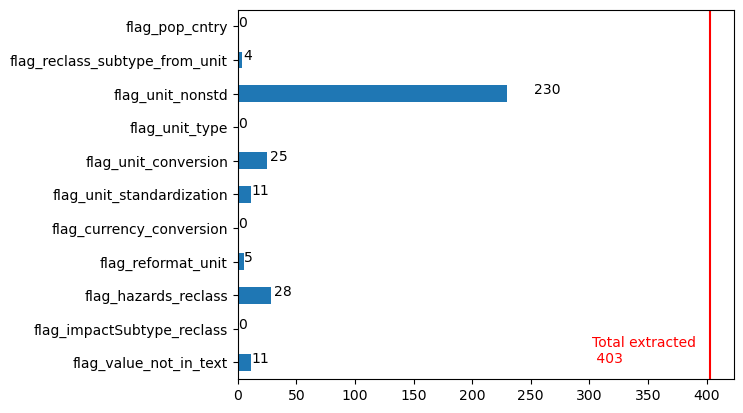

In [5]:
ax = extracted_df[flag_cols].sum().plot(kind="barh")
ax.axvline(len(extracted_df), color="red")
ax.text(len(extracted_df)*0.75, 0, f"Total extracted\n {len(extracted_df)}", color="red")
for i, v in enumerate(extracted_df[flag_cols].sum()):
    ax.text(v*1.1, i, f"{v}", color="black")
#extracted_df[["appealCode"]+ flag_cols].plot(kind="barh")

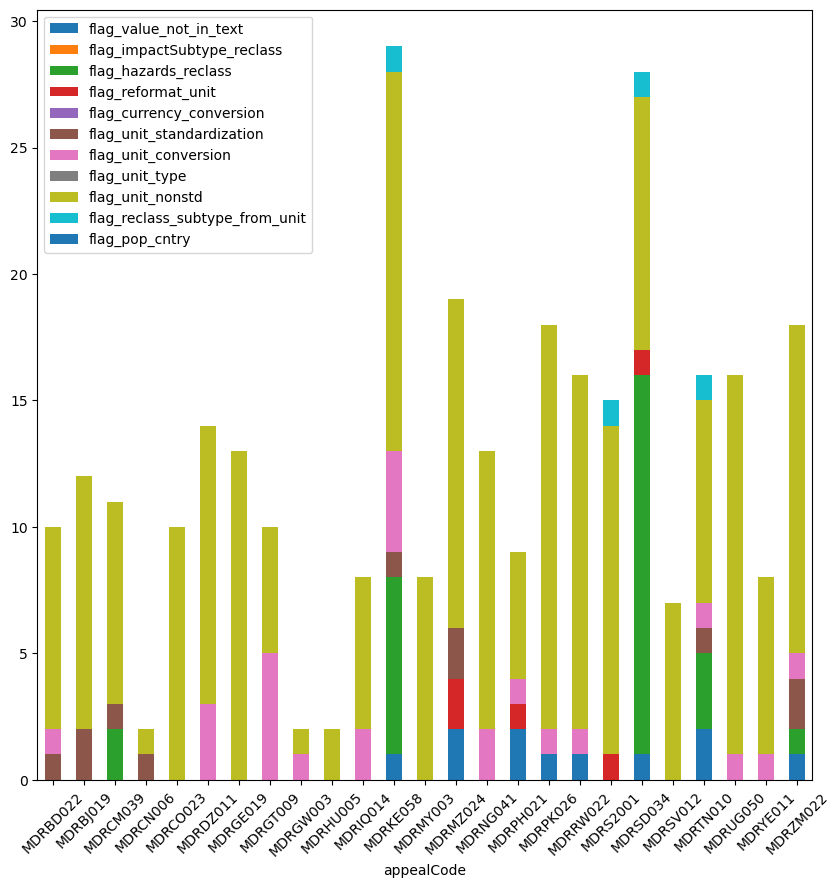

In [6]:
ax = extracted_df.groupby("appealCode")[flag_cols].sum().plot(kind="bar", figsize=(10,10), rot=45, stacked=True)

In [8]:
extracted_df[extracted_df["appealCode"] == "MDRSD034"][["hazards", "flag_hazards_reclass"]]

,hazards,flag_hazards_reclass
24,"[Flood, Epidemics, Conflict]",True
25,"[Flood, Epidemics]",True
26,[Flood],False
27,"[Flood, Epidemics, Conflict]",True
28,"[Flood, Epidemics, Conflict]",True
29,"[Flood, Epidemics]",True
30,"[Flood, Conflict, Epidemics]",True
31,[Flood],False
32,"[Conflict, Flood, Epidemics]",True
33,[Flood],False
